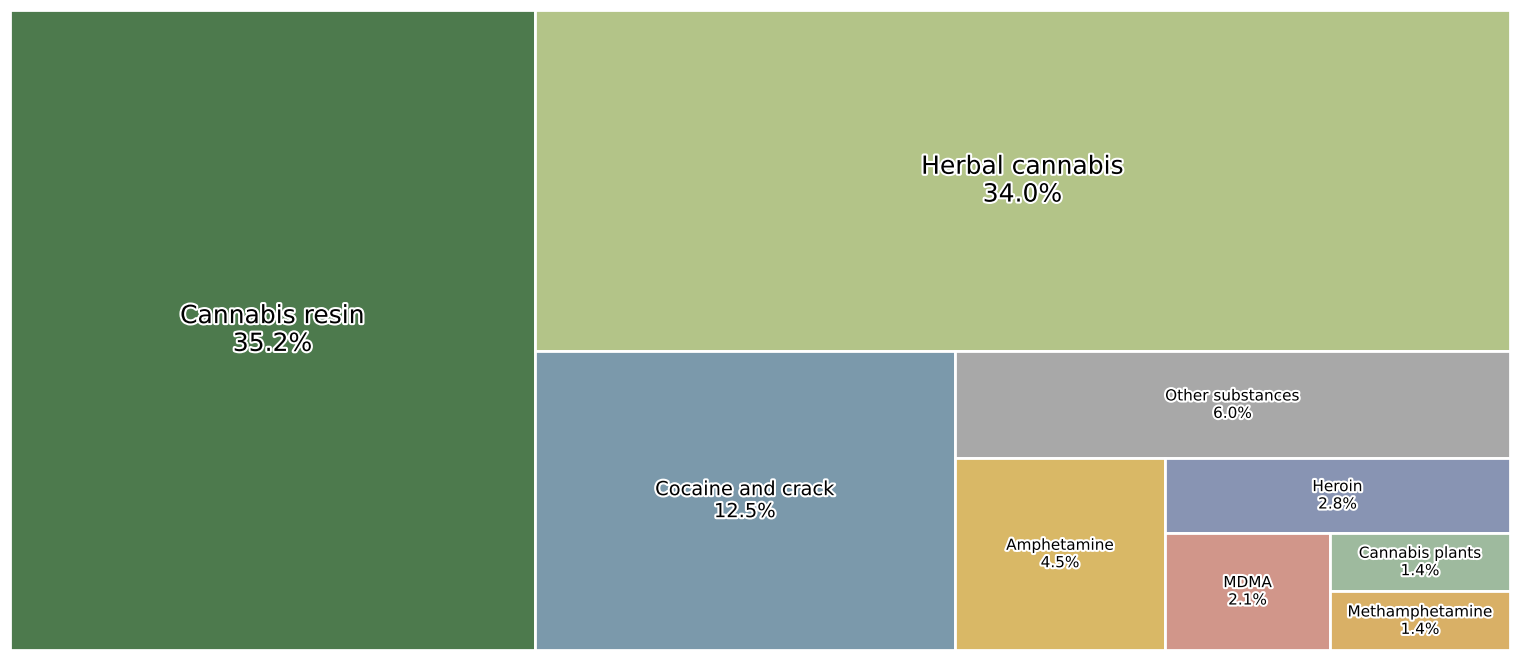

<Figure size 640x480 with 0 Axes>

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.patches import Rectangle
import pandas as pd

df = pd.read_csv("sequestri_europa.csv", sep=';')
perc_data = dict(zip(df['Substance'], df['Percentage']))

fig, ax = plt.subplots(figsize=(15, 6.4))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

colors = {
    "resin": "#4D7A4D",
    "herbal": "#B3C488",
    "cocaine": "#7B99AB",
    "other": "#A8A8A8",
    "amphetamine": "#D9B866",
    "heroin": "#8894B3",
    "mdma": "#D1968A",
    "plants": "#9EBA9E",
    "meth": "#D9B066"
}

rectangles = [
    {"xy": (0, 0), "w": 35, "h": 60, "label": "Cannabis resin", "color": colors["resin"]},
    {"xy": (35, 0), "w": 65, "h": 32, "label": "Herbal cannabis", "color": colors["herbal"]},
    {"xy": (35, 32), "w": 28, "h": 28, "label": "Cocaine and crack", "color": colors["cocaine"]},
    {"xy": (63, 32), "w": 37, "h": 10, "label": "Other substances", "color": colors["other"]},
    {"xy": (63, 42), "w": 14, "h": 18, "label": "Amphetamine", "color": colors["amphetamine"]},
    {"xy": (77, 42), "w": 23, "h": 7, "label": "Heroin", "color": colors["heroin"]},
    {"xy": (77, 49), "w": 11, "h": 11, "label": "MDMA", "color": colors["mdma"]},
    {"xy": (88, 49), "w": 12, "h": 5.5, "label": "Cannabis plants", "color": colors["plants"]},
    {"xy": (88, 54.5), "w": 12, "h": 5.5, "label": "Methamphetamine", "color": colors["meth"]}
]

for r in rectangles:
    x, y = r["xy"]
    w = r["w"]
    h = r["h"]

    rect = Rectangle((x, y), w, h, facecolor=r["color"], edgecolor="white", linewidth=2)
    ax.add_patch(rect)

    p = perc_data.get(r["label"], 0)
    display_text = f"{r['label']}\n{p}%"

    area = w * h
    fontsize = 18 if area > 1200 else (14 if area > 400 else 11)

    txt = ax.text(x + w / 2, y + h / 2, display_text, ha="center", va="center", 
                  fontsize=fontsize, color="black", family="sans-serif")

    txt.set_path_effects([pe.withStroke(linewidth=3, foreground="white")])

ax.set_xlim(0, 100)
ax.set_ylim(60, 0)
ax.axis("off")
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

plt.show()
plt.savefig("treemap_exact_layout.png", dpi=300, bbox_inches="tight", pad_inches=0)